In [ ]:
! pip install torch_geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.1/63.1 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 15.6 MB/s eta 0:00:00


### PROTEINS

In [ ]:
import numpy as np
import torch
from torch_geometric.datasets import TUDataset
from torch_geometric.data import DataLoader
import torch.nn.functional as F
import torch.optim as optim
from torch_geometric.nn import GCNConv
from torch_geometric.utils import to_dense_batch
from scipy.optimize import minimize
import random
import pandas as pd
from sklearn.metrics import precision_score, recall_score
import time

# Definition of the loss function and IMV calculation
def ll(x, p):
    z = (np.log(p + 1e-9) * x) + (np.log(1 - p + 1e-9) * (1 - x))
    return np.exp(np.sum(z) / len(z))

def get_w(a, guess=0.5, bounds=[(0.5, 0.999)]):
    res = minimize(minimize_me, guess, args=a,
                   options={'ftol': 0, 'gtol': 1e-20},
                   method='L-BFGS-B', bounds=bounds)
    return res['x'][0]

def minimize_me(p, a):
    return abs((p * np.log(p)) + ((1 - p) * np.log(1 - p)) - np.log(a))

def calculate_imv(y_basic, y_enhanced, y):
    ll_basic = ll(y, y_basic)
    ll_enhanced = ll(y, y_enhanced)
    w0 = get_w(ll_basic)
    w1 = get_w(ll_enhanced)
    return (w1 - w0) / w0

# Define the GCN model
class HierarchicalGCN_TOPK(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, num_classes):
        super(HierarchicalGCN_TOPK, self).__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.conv3 = GCNConv(hidden_channels, out_channels)
        self.lin1 = torch.nn.Linear(out_channels, 32)
        self.lin2 = torch.nn.Linear(32, num_classes)

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)
        x = F.relu(x)
        x = self.conv3(x, edge_index)
        x = F.relu(x)
        x, mask = to_dense_batch(x, batch)
        x = x.mean(dim=1)
        x = self.lin1(x).relu()
        x = self.lin2(x)
        return F.log_softmax(x, dim=-1)

# Load dataset and prepare data
max_nodes = 150
data_path = "/content/sample_data"
dataset_sparse = TUDataset(root=data_path, name="PROTEINS",
                           pre_filter=lambda data: data.num_nodes <= max_nodes, use_node_attr=True)

# Function to split the dataset
def split_dataset(dataset, train_ratio=0.7, val_ratio=0.15):
    dataset = dataset.shuffle()
    num_total = len(dataset)
    num_train = int(num_total * train_ratio)
    num_val = int(num_total * val_ratio)
    num_test = num_total - num_train - num_val
    train_dataset = dataset[:num_train]
    val_dataset = dataset[num_train:num_train + num_val]
    test_dataset = dataset[num_train + num_val:]
    return train_dataset, val_dataset, test_dataset

# Set random seeds
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Training and testing functions
def train():
    model.train()
    total_loss = 0
    for data in train_loader:
        data = data.to(device)
        optimizer.zero_grad()
        out = model(data)
        loss = F.nll_loss(out, data.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * data.num_graphs
    return total_loss / len(train_loader.dataset)

def test(loader):
    model.eval()
    correct = 0
    all_probs = []
    all_labels = []
    all_preds = []
    for data in loader:
        data = data.to(device)
        out = model(data)
        probs = torch.exp(out[:, 1])  # Get probabilities for class 1
        all_probs.append(probs.cpu().detach().numpy())
        all_labels.append(data.y.cpu().numpy())  # Get the actual labels
        pred = out.argmax(dim=1)
        all_preds.append(pred.cpu().numpy())
        correct += (pred == data.y).sum().item()
    return correct / len(loader.dataset), np.concatenate(all_probs), np.concatenate(all_labels), np.concatenate(all_preds)

# Parameters
seeds = [42]
early_stop_patience = 200
tolerance = 0.0001
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Start timer
start_time = time.time()

# Storage for IMV and other metrics, separate by seed
all_seed_metrics = []

for seed in seeds:
    set_seed(seed)
    train_dataset, val_dataset, test_dataset = split_dataset(dataset_sparse)
    train_loader = DataLoader(train_dataset, batch_size=512, shuffle=True)
    valid_loader = DataLoader(val_dataset, batch_size=512, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=512, shuffle=False)

    model = HierarchicalGCN_TOPK(in_channels=dataset_sparse.num_features, hidden_channels=64, out_channels=64, num_classes=dataset_sparse.num_classes).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    best_val_acc = 0
    epochs_no_improve = 0

    # Calculate the ratio of class 1 in the training set
    y_train = np.concatenate([data.y.cpu().numpy() for data in train_loader])
    class_1_ratio = np.mean(y_train == 1)  # Proportion of class 1
    print(f"Class 1 ratio in training set: {class_1_ratio}")

    y_basic = np.full((len(test_dataset),), class_1_ratio)  # Initialize y_basic as a vector with the class 1 ratio

    # Metrics for the current seed
    seed_metrics = {'epoch': [], 'test_acc': [], 'precision': [], 'recall': [], 'imv': []}

    for epoch in range(1, 201):
        loss = train()
        val_acc, _, _, _ = test(valid_loader)
        test_acc, y_enhanced, y_test, y_pred = test(test_loader)  # Get test accuracy, probabilities, labels, and predictions

        # Calculate precision, recall, and IMV
        precision = precision_score(y_test, y_pred, average='macro', zero_division=0)
        recall = recall_score(y_test, y_pred, average='macro', zero_division=0)

        imv_value = calculate_imv(y_basic, y_enhanced, y_test == 1)  # Calculate IMV from epoch 1

        # Append metrics to the current seed
        seed_metrics['epoch'].append(epoch)
        seed_metrics['test_acc'].append(test_acc)
        seed_metrics['precision'].append(precision)
        seed_metrics['recall'].append(recall)
        seed_metrics['imv'].append(imv_value)

        # Print metrics for current epoch
        print(f"Epoch {epoch}: Test Acc = {test_acc:.4f}, Precision = {precision:.4f}, Recall = {recall:.4f}, IMV = {imv_value}")

        # Early stopping condition
        if val_acc > best_val_acc + tolerance:
            best_val_acc = val_acc
            best_test_acc = test_acc
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= early_stop_patience:
            print(f'Early stopping at epoch {epoch} for seed {seed}')
            break

    torch.cuda.empty_cache()

    # Store metrics for this seed
    all_seed_metrics.append(pd.DataFrame(seed_metrics))

# Combine all seed data into one DataFrame, concatenating horizontally
combined_df = pd.concat(all_seed_metrics, axis=1, keys=[f'seed_{seed}' for seed in seeds])

# Save to CSV
output_path = "/content/sample_data/epoch_metrics_by_seed.csv"
combined_df.to_csv(output_path)

# End timer
end_time = time.time()
total_time = end_time - start_time
print(f"Metrics saved to {output_path}")
print(f"Total time for execution with one seed: {total_time:.2f} seconds")


Class 1 ratio in training set: 0.4163372859025033
Epoch 1: Test Acc = 0.4695, Precision = 0.2348, Recall = 0.5000, IMV = 0.0
Epoch 2: Test Acc = 0.4756, Precision = 0.5080, Recall = 0.5020, IMV = 0.06451304925973345
Epoch 3: Test Acc = 0.5793, Precision = 0.6406, Recall = 0.5967, IMV = 0.1248768462193337
Epoch 4: Test Acc = 0.6707, Precision = 0.6911, Recall = 0.6792, IMV = 0.16257111308393002
Epoch 5: Test Acc = 0.7378, Precision = 0.7396, Recall = 0.7335, IMV = 0.19023015761535467
Epoch 6: Test Acc = 0.6890, Precision = 0.7285, Recall = 0.6748, IMV = 0.2109875305021145
Epoch 7: Test Acc = 0.6098, Precision = 0.6821, Recall = 0.5881, IMV = 0.22886622316629812
Epoch 8: Test Acc = 0.5610, Precision = 0.6085, Recall = 0.5362, IMV = 0.24037900572663662
Epoch 9: Test Acc = 0.5488, Precision = 0.6278, Recall = 0.5210, IMV = 0.2430862434001675
Epoch 10: Test Acc = 0.5366, Precision = 0.5673, Recall = 0.5080, IMV = 0.2353608783501524
Epoch 11: Test Acc = 0.5366, Precision = 0.6004, Recall = 0

In [ ]:
import numpy as np
import torch
from torch_geometric.datasets import TUDataset
from torch_geometric.data import DataLoader
import torch.nn.functional as F
import torch.optim as optim
from torch_geometric.nn import GCNConv
from torch_geometric.utils import to_dense_batch
import random
import pandas as pd
from sklearn.metrics import precision_score, recall_score
import time

# Define the GCN model
class HierarchicalGCN_TOPK(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, num_classes):
        super(HierarchicalGCN_TOPK, self).__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.conv3 = GCNConv(hidden_channels, out_channels)
        self.lin1 = torch.nn.Linear(out_channels, 32)
        self.lin2 = torch.nn.Linear(32, num_classes)

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)
        x = F.relu(x)
        x = self.conv3(x, edge_index)
        x = F.relu(x)
        x, mask = to_dense_batch(x, batch)
        x = x.mean(dim=1)
        x = self.lin1(x).relu()
        x = self.lin2(x)
        return F.log_softmax(x, dim=-1)

# Load dataset and prepare data
max_nodes = 150
data_path = "/content/sample_data"
dataset_sparse = TUDataset(root=data_path, name="PROTEINS",
                           pre_filter=lambda data: data.num_nodes <= max_nodes, use_node_attr=True)

# Function to split the dataset
def split_dataset(dataset, train_ratio=0.7, val_ratio=0.15):
    dataset = dataset.shuffle()
    num_total = len(dataset)
    num_train = int(num_total * train_ratio)
    num_val = int(num_total * val_ratio)
    num_test = num_total - num_train - num_val
    train_dataset = dataset[:num_train]
    val_dataset = dataset[num_train:num_train + num_val]
    test_dataset = dataset[num_train + num_val:]
    return train_dataset, val_dataset, test_dataset

# Set random seeds
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Training and testing functions
def train():
    model.train()
    total_loss = 0
    for data in train_loader:
        data = data.to(device)
        optimizer.zero_grad()
        out = model(data)
        loss = F.nll_loss(out, data.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * data.num_graphs
    return total_loss / len(train_loader.dataset)

def test(loader):
    model.eval()
    correct = 0
    all_probs = []
    all_labels = []
    all_preds = []
    for data in loader:
        data = data.to(device)
        out = model(data)
        probs = torch.exp(out[:, 1])  # Get probabilities for class 1
        all_probs.append(probs.cpu().detach().numpy())
        all_labels.append(data.y.cpu().numpy())  # Get the actual labels
        pred = out.argmax(dim=1)
        all_preds.append(pred.cpu().numpy())
        correct += (pred == data.y).sum().item()
    return correct / len(loader.dataset), np.concatenate(all_probs), np.concatenate(all_labels), np.concatenate(all_preds)

# Parameters
seeds = [42]
early_stop_patience = 200
tolerance = 0.0001
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Start timer
start_time = time.time()

# Storage for metrics, separate by seed
all_seed_metrics = []

for seed in seeds:
    set_seed(seed)
    train_dataset, val_dataset, test_dataset = split_dataset(dataset_sparse)
    train_loader = DataLoader(train_dataset, batch_size=512, shuffle=True)
    valid_loader = DataLoader(val_dataset, batch_size=512, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=512, shuffle=False)

    model = HierarchicalGCN_TOPK(in_channels=dataset_sparse.num_features, hidden_channels=64, out_channels=64, num_classes=dataset_sparse.num_classes).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    best_val_acc = 0
    epochs_no_improve = 0

    # Calculate the ratio of class 1 in the training set
    y_train = np.concatenate([data.y.cpu().numpy() for data in train_loader])
    #class_1_ratio = np.mean(y_train == 1)  # Proportion of class 1
    #print(f"Class 1 ratio in training set: {class_1_ratio}")

    # Metrics for the current seed
    seed_metrics = {'epoch': [], 'test_acc': [], 'precision': [], 'recall': []}

    for epoch in range(1, 201):
        loss = train()
        val_acc, _, _, _ = test(valid_loader)
        test_acc, _, y_test, y_pred = test(test_loader)  # Get test accuracy, probabilities, labels, and predictions

        # Calculate precision and recall
        precision = precision_score(y_test, y_pred, average='macro', zero_division=0)
        recall = recall_score(y_test, y_pred, average='macro', zero_division=0)

        # Append metrics to the current seed
        seed_metrics['epoch'].append(epoch)
        seed_metrics['test_acc'].append(test_acc)
        seed_metrics['precision'].append(precision)
        seed_metrics['recall'].append(recall)

        # Print metrics for current epoch
        print(f"Epoch {epoch}: Test Acc = {test_acc:.4f}, Precision = {precision:.4f}, Recall = {recall:.4f}")

        # Early stopping condition
        if val_acc > best_val_acc + tolerance:
            best_val_acc = val_acc
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= early_stop_patience:
            print(f'Early stopping at epoch {epoch} for seed {seed}')
            break

    torch.cuda.empty_cache()

    # Store metrics for this seed
    all_seed_metrics.append(pd.DataFrame(seed_metrics))

# Combine all seed data into one DataFrame, concatenating horizontally
combined_df = pd.concat(all_seed_metrics, axis=1, keys=[f'seed_{seed}' for seed in seeds])

# Save to CSV
output_path = "/content/sample_data/epoch_metrics_by_seed.csv"
combined_df.to_csv(output_path)

# End timer
end_time = time.time()
total_time = end_time - start_time
print(f"Metrics saved to {output_path}")
print(f"Total time for execution with one seed: {total_time:.2f} seconds")


Epoch 1: Test Acc = 0.4695, Precision = 0.2348, Recall = 0.5000
Epoch 2: Test Acc = 0.4756, Precision = 0.5080, Recall = 0.5020
Epoch 3: Test Acc = 0.5793, Precision = 0.6406, Recall = 0.5967
Epoch 4: Test Acc = 0.6707, Precision = 0.6911, Recall = 0.6792
Epoch 5: Test Acc = 0.7378, Precision = 0.7396, Recall = 0.7335
Epoch 6: Test Acc = 0.6890, Precision = 0.7285, Recall = 0.6748
Epoch 7: Test Acc = 0.6098, Precision = 0.6821, Recall = 0.5881
Epoch 8: Test Acc = 0.5610, Precision = 0.6085, Recall = 0.5362
Epoch 9: Test Acc = 0.5488, Precision = 0.6278, Recall = 0.5210
Epoch 10: Test Acc = 0.5366, Precision = 0.5673, Recall = 0.5080
Epoch 11: Test Acc = 0.5366, Precision = 0.6004, Recall = 0.5072
Epoch 12: Test Acc = 0.5427, Precision = 0.7685, Recall = 0.5130
Epoch 13: Test Acc = 0.5366, Precision = 0.7669, Recall = 0.5065
Epoch 14: Test Acc = 0.5427, Precision = 0.7685, Recall = 0.5130
Epoch 15: Test Acc = 0.5427, Precision = 0.7685, Recall = 0.5130
Epoch 16: Test Acc = 0.5366, Preci

## NCI1

In [ ]:
import numpy as np
import torch
from torch_geometric.datasets import TUDataset
from torch_geometric.data import DataLoader
import torch.nn.functional as F
import torch.optim as optim
from torch_geometric.nn import GCNConv
from torch_geometric.utils import to_dense_batch
from scipy.optimize import minimize
import random
import pandas as pd
from sklearn.metrics import precision_score, recall_score
import time

# Definition of the loss function and IMV calculation
def ll(x, p):
    z = (np.log(p + 1e-9) * x) + (np.log(1 - p + 1e-9) * (1 - x))
    return np.exp(np.sum(z) / len(z))

def get_w(a, guess=0.5, bounds=[(0.5, 0.999)]):
    res = minimize(minimize_me, guess, args=a,
                   options={'ftol': 0, 'gtol': 1e-20},
                   method='L-BFGS-B', bounds=bounds)
    return res['x'][0]

def minimize_me(p, a):
    return abs((p * np.log(p)) + ((1 - p) * np.log(1 - p)) - np.log(a))

def calculate_imv(y_basic, y_enhanced, y):
    ll_basic = ll(y, y_basic)
    ll_enhanced = ll(y, y_enhanced)
    w0 = get_w(ll_basic)
    w1 = get_w(ll_enhanced)
    return (w1 - w0) / w0

# Define the GCN model
class HierarchicalGCN_TOPK(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, num_classes):
        super(HierarchicalGCN_TOPK, self).__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.conv3 = GCNConv(hidden_channels, out_channels)
        self.lin1 = torch.nn.Linear(out_channels, 32)
        self.lin2 = torch.nn.Linear(32, num_classes)

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)
        x = F.relu(x)
        x = self.conv3(x, edge_index)
        x = F.relu(x)
        x, mask = to_dense_batch(x, batch)
        x = x.mean(dim=1)
        x = self.lin1(x).relu()
        x = self.lin2(x)
        return F.log_softmax(x, dim=-1)

# Load dataset and prepare data
max_nodes = 150
data_path = "/content/sample_data"
dataset_sparse = TUDataset(root=data_path, name="NCI1",
                           pre_filter=lambda data: data.num_nodes <= max_nodes, use_node_attr=True)

# Function to split the dataset
def split_dataset(dataset, train_ratio=0.7, val_ratio=0.15):
    dataset = dataset.shuffle()
    num_total = len(dataset)
    num_train = int(num_total * train_ratio)
    num_val = int(num_total * val_ratio)
    num_test = num_total - num_train - num_val
    train_dataset = dataset[:num_train]
    val_dataset = dataset[num_train:num_train + num_val]
    test_dataset = dataset[num_train + num_val:]
    return train_dataset, val_dataset, test_dataset

# Set random seeds
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Training and testing functions
def train():
    model.train()
    total_loss = 0
    for data in train_loader:
        data = data.to(device)
        optimizer.zero_grad()
        out = model(data)
        loss = F.nll_loss(out, data.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * data.num_graphs
    return total_loss / len(train_loader.dataset)

def test(loader):
    model.eval()
    correct = 0
    all_probs = []
    all_labels = []
    all_preds = []
    for data in loader:
        data = data.to(device)
        out = model(data)
        probs = torch.exp(out[:, 1])  # Get probabilities for class 1
        all_probs.append(probs.cpu().detach().numpy())
        all_labels.append(data.y.cpu().numpy())  # Get the actual labels
        pred = out.argmax(dim=1)
        all_preds.append(pred.cpu().numpy())
        correct += (pred == data.y).sum().item()
    return correct / len(loader.dataset), np.concatenate(all_probs), np.concatenate(all_labels), np.concatenate(all_preds)

# Parameters
seeds = [42]
early_stop_patience = 200
tolerance = 0.0001
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Start timer
start_time = time.time()

# Storage for IMV and other metrics, separate by seed
all_seed_metrics = []

for seed in seeds:
    set_seed(seed)
    train_dataset, val_dataset, test_dataset = split_dataset(dataset_sparse)
    train_loader = DataLoader(train_dataset, batch_size=512, shuffle=True)
    valid_loader = DataLoader(val_dataset, batch_size=512, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=512, shuffle=False)

    model = HierarchicalGCN_TOPK(in_channels=dataset_sparse.num_features, hidden_channels=64, out_channels=64, num_classes=dataset_sparse.num_classes).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    best_val_acc = 0
    epochs_no_improve = 0

    # Calculate the ratio of class 1 in the training set
    y_train = np.concatenate([data.y.cpu().numpy() for data in train_loader])
    class_1_ratio = np.mean(y_train == 1)  # Proportion of class 1
    print(f"Class 1 ratio in training set: {class_1_ratio}")

    y_basic = np.full((len(test_dataset),), class_1_ratio)  # Initialize y_basic as a vector with the class 1 ratio

    # Metrics for the current seed
    seed_metrics = {'epoch': [], 'test_acc': [], 'precision': [], 'recall': [], 'imv': []}

    for epoch in range(1, 201):
        loss = train()
        val_acc, _, _, _ = test(valid_loader)
        test_acc, y_enhanced, y_test, y_pred = test(test_loader)  # Get test accuracy, probabilities, labels, and predictions

        # Calculate precision, recall, and IMV
        precision = precision_score(y_test, y_pred, average='macro', zero_division=0)
        recall = recall_score(y_test, y_pred, average='macro', zero_division=0)

        imv_value = calculate_imv(y_basic, y_enhanced, y_test == 1)  # Calculate IMV from epoch 1

        # Append metrics to the current seed
        seed_metrics['epoch'].append(epoch)
        seed_metrics['test_acc'].append(test_acc)
        seed_metrics['precision'].append(precision)
        seed_metrics['recall'].append(recall)
        seed_metrics['imv'].append(imv_value)

        # Print metrics for current epoch
        print(f"Epoch {epoch}: Test Acc = {test_acc:.4f}, Precision = {precision:.4f}, Recall = {recall:.4f}, IMV = {imv_value}")

        # Early stopping condition
        if val_acc > best_val_acc + tolerance:
            best_val_acc = val_acc
            best_test_acc = test_acc
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= early_stop_patience:
            print(f'Early stopping at epoch {epoch} for seed {seed}')
            break

    torch.cuda.empty_cache()

    # Store metrics for this seed
    all_seed_metrics.append(pd.DataFrame(seed_metrics))

# Combine all seed data into one DataFrame, concatenating horizontally
combined_df = pd.concat(all_seed_metrics, axis=1, keys=[f'seed_{seed}' for seed in seeds])

# Save to CSV
output_path = "/content/sample_data/epoch_metrics_by_seed.csv"
combined_df.to_csv(output_path)

# End timer
end_time = time.time()
total_time = end_time - start_time
print(f"Metrics saved to {output_path}")
print(f"Total time for execution with one seed: {total_time:.2f} seconds")


Class 1 ratio in training set: 0.5123392422662496
Epoch 1: Test Acc = 0.4619, Precision = 0.2310, Recall = 0.5000, IMV = 0.0
Epoch 2: Test Acc = 0.4619, Precision = 0.2310, Recall = 0.5000, IMV = 0.0
Epoch 3: Test Acc = 0.4619, Precision = 0.2310, Recall = 0.5000, IMV = 0.0
Epoch 4: Test Acc = 0.4619, Precision = 0.2310, Recall = 0.5000, IMV = 0.0
Epoch 5: Test Acc = 0.4619, Precision = 0.2310, Recall = 0.5000, IMV = 0.03432269879795835
Epoch 6: Test Acc = 0.4619, Precision = 0.2310, Recall = 0.5000, IMV = 0.09015456413621181
Epoch 7: Test Acc = 0.4749, Precision = 0.6267, Recall = 0.5113, IMV = 0.12476015091217829
Epoch 8: Test Acc = 0.4943, Precision = 0.5923, Recall = 0.5266, IMV = 0.15939112011639667
Epoch 9: Test Acc = 0.5073, Precision = 0.5943, Recall = 0.5372, IMV = 0.17547541044167803
Epoch 10: Test Acc = 0.5867, Precision = 0.6165, Recall = 0.6013, IMV = 0.21582695410387642
Epoch 11: Test Acc = 0.5737, Precision = 0.6079, Recall = 0.5900, IMV = 0.22758651811941144
Epoch 12: T

In [ ]:
import numpy as np
import torch
from torch_geometric.datasets import TUDataset
from torch_geometric.data import DataLoader
import torch.nn.functional as F
import torch.optim as optim
from torch_geometric.nn import GCNConv
from torch_geometric.utils import to_dense_batch
import random
import pandas as pd
from sklearn.metrics import precision_score, recall_score
import time

# Define the GCN model
class HierarchicalGCN_TOPK(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, num_classes):
        super(HierarchicalGCN_TOPK, self).__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.conv3 = GCNConv(hidden_channels, out_channels)
        self.lin1 = torch.nn.Linear(out_channels, 32)
        self.lin2 = torch.nn.Linear(32, num_classes)

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)
        x = F.relu(x)
        x = self.conv3(x, edge_index)
        x = F.relu(x)
        x, mask = to_dense_batch(x, batch)
        x = x.mean(dim=1)
        x = self.lin1(x).relu()
        x = self.lin2(x)
        return F.log_softmax(x, dim=-1)

# Load dataset and prepare data
max_nodes = 150
data_path = "/content/sample_data"
dataset_sparse = TUDataset(root=data_path, name="NCI1",
                           pre_filter=lambda data: data.num_nodes <= max_nodes, use_node_attr=True)

# Function to split the dataset
def split_dataset(dataset, train_ratio=0.7, val_ratio=0.15):
    dataset = dataset.shuffle()
    num_total = len(dataset)
    num_train = int(num_total * train_ratio)
    num_val = int(num_total * val_ratio)
    num_test = num_total - num_train - num_val
    train_dataset = dataset[:num_train]
    val_dataset = dataset[num_train:num_train + num_val]
    test_dataset = dataset[num_train + num_val:]
    return train_dataset, val_dataset, test_dataset

# Set random seeds
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Training and testing functions
def train():
    model.train()
    total_loss = 0
    for data in train_loader:
        data = data.to(device)
        optimizer.zero_grad()
        out = model(data)
        loss = F.nll_loss(out, data.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * data.num_graphs
    return total_loss / len(train_loader.dataset)

def test(loader):
    model.eval()
    correct = 0
    all_probs = []
    all_labels = []
    all_preds = []
    for data in loader:
        data = data.to(device)
        out = model(data)
        probs = torch.exp(out[:, 1])  # Get probabilities for class 1
        all_probs.append(probs.cpu().detach().numpy())
        all_labels.append(data.y.cpu().numpy())  # Get the actual labels
        pred = out.argmax(dim=1)
        all_preds.append(pred.cpu().numpy())
        correct += (pred == data.y).sum().item()
    return correct / len(loader.dataset), np.concatenate(all_probs), np.concatenate(all_labels), np.concatenate(all_preds)

# Parameters
seeds = [42]
early_stop_patience = 200
tolerance = 0.0001
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Start timer
start_time = time.time()

# Storage for metrics, separate by seed
all_seed_metrics = []

for seed in seeds:
    set_seed(seed)
    train_dataset, val_dataset, test_dataset = split_dataset(dataset_sparse)
    train_loader = DataLoader(train_dataset, batch_size=512, shuffle=True)
    valid_loader = DataLoader(val_dataset, batch_size=512, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=512, shuffle=False)

    model = HierarchicalGCN_TOPK(in_channels=dataset_sparse.num_features, hidden_channels=64, out_channels=64, num_classes=dataset_sparse.num_classes).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    best_val_acc = 0
    epochs_no_improve = 0

    # Calculate the ratio of class 1 in the training set
    y_train = np.concatenate([data.y.cpu().numpy() for data in train_loader])
    #class_1_ratio = np.mean(y_train == 1)  # Proportion of class 1
    #print(f"Class 1 ratio in training set: {class_1_ratio}")

    # Metrics for the current seed
    seed_metrics = {'epoch': [], 'test_acc': [], 'precision': [], 'recall': []}

    for epoch in range(1, 201):
        loss = train()
        val_acc, _, _, _ = test(valid_loader)
        test_acc, _, y_test, y_pred = test(test_loader)  # Get test accuracy, probabilities, labels, and predictions

        # Calculate precision and recall
        precision = precision_score(y_test, y_pred, average='macro', zero_division=0)
        recall = recall_score(y_test, y_pred, average='macro', zero_division=0)

        # Append metrics to the current seed
        seed_metrics['epoch'].append(epoch)
        seed_metrics['test_acc'].append(test_acc)
        seed_metrics['precision'].append(precision)
        seed_metrics['recall'].append(recall)

        # Print metrics for current epoch
        print(f"Epoch {epoch}: Test Acc = {test_acc:.4f}, Precision = {precision:.4f}, Recall = {recall:.4f}")

        # Early stopping condition
        if val_acc > best_val_acc + tolerance:
            best_val_acc = val_acc
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= early_stop_patience:
            print(f'Early stopping at epoch {epoch} for seed {seed}')
            break

    torch.cuda.empty_cache()

    # Store metrics for this seed
    all_seed_metrics.append(pd.DataFrame(seed_metrics))

# Combine all seed data into one DataFrame, concatenating horizontally
combined_df = pd.concat(all_seed_metrics, axis=1, keys=[f'seed_{seed}' for seed in seeds])

# Save to CSV
output_path = "/content/sample_data/epoch_metrics_by_seed.csv"
combined_df.to_csv(output_path)

# End timer
end_time = time.time()
total_time = end_time - start_time
print(f"Metrics saved to {output_path}")
print(f"Total time for execution with one seed: {total_time:.2f} seconds")

Epoch 1: Test Acc = 0.4619, Precision = 0.2310, Recall = 0.5000
Epoch 2: Test Acc = 0.4619, Precision = 0.2310, Recall = 0.5000
Epoch 3: Test Acc = 0.4619, Precision = 0.2310, Recall = 0.5000
Epoch 4: Test Acc = 0.4619, Precision = 0.2310, Recall = 0.5000
Epoch 5: Test Acc = 0.4619, Precision = 0.2310, Recall = 0.5000
Epoch 6: Test Acc = 0.4619, Precision = 0.2310, Recall = 0.5000
Epoch 7: Test Acc = 0.4749, Precision = 0.6267, Recall = 0.5113
Epoch 8: Test Acc = 0.4943, Precision = 0.5923, Recall = 0.5266
Epoch 9: Test Acc = 0.5073, Precision = 0.5943, Recall = 0.5372
Epoch 10: Test Acc = 0.5867, Precision = 0.6165, Recall = 0.6013
Epoch 11: Test Acc = 0.5737, Precision = 0.6079, Recall = 0.5900
Epoch 12: Test Acc = 0.5883, Precision = 0.6135, Recall = 0.6016
Epoch 13: Test Acc = 0.6207, Precision = 0.6181, Recall = 0.6175
Epoch 14: Test Acc = 0.6029, Precision = 0.6096, Recall = 0.6084
Epoch 15: Test Acc = 0.6045, Precision = 0.6057, Recall = 0.6062
Epoch 16: Test Acc = 0.6143, Preci

## NCI109

In [ ]:
import numpy as np
import torch
from torch_geometric.datasets import TUDataset
from torch_geometric.data import DataLoader
import torch.nn.functional as F
import torch.optim as optim
from torch_geometric.nn import GCNConv
from torch_geometric.utils import to_dense_batch
from scipy.optimize import minimize
import random
import pandas as pd
from sklearn.metrics import precision_score, recall_score
import time

# Definition of the loss function and IMV calculation
def ll(x, p):
    z = (np.log(p + 1e-9) * x) + (np.log(1 - p + 1e-9) * (1 - x))
    return np.exp(np.sum(z) / len(z))

def get_w(a, guess=0.5, bounds=[(0.5, 0.999)]):
    res = minimize(minimize_me, guess, args=a,
                   options={'ftol': 0, 'gtol': 1e-20},
                   method='L-BFGS-B', bounds=bounds)
    return res['x'][0]

def minimize_me(p, a):
    return abs((p * np.log(p)) + ((1 - p) * np.log(1 - p)) - np.log(a))

def calculate_imv(y_basic, y_enhanced, y):
    ll_basic = ll(y, y_basic)
    ll_enhanced = ll(y, y_enhanced)
    w0 = get_w(ll_basic)
    w1 = get_w(ll_enhanced)
    return (w1 - w0) / w0

# Define the GCN model
class HierarchicalGCN_TOPK(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, num_classes):
        super(HierarchicalGCN_TOPK, self).__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.conv3 = GCNConv(hidden_channels, out_channels)
        self.lin1 = torch.nn.Linear(out_channels, 32)
        self.lin2 = torch.nn.Linear(32, num_classes)

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)
        x = F.relu(x)
        x = self.conv3(x, edge_index)
        x = F.relu(x)
        x, mask = to_dense_batch(x, batch)
        x = x.mean(dim=1)
        x = self.lin1(x).relu()
        x = self.lin2(x)
        return F.log_softmax(x, dim=-1)

# Load dataset and prepare data
max_nodes = 150
data_path = "/content/sample_data"
dataset_sparse = TUDataset(root=data_path, name="NCI109",
                           pre_filter=lambda data: data.num_nodes <= max_nodes, use_node_attr=True)

# Function to split the dataset
def split_dataset(dataset, train_ratio=0.7, val_ratio=0.15):
    dataset = dataset.shuffle()
    num_total = len(dataset)
    num_train = int(num_total * train_ratio)
    num_val = int(num_total * val_ratio)
    num_test = num_total - num_train - num_val
    train_dataset = dataset[:num_train]
    val_dataset = dataset[num_train:num_train + num_val]
    test_dataset = dataset[num_train + num_val:]
    return train_dataset, val_dataset, test_dataset

# Set random seeds
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Training and testing functions
def train():
    model.train()
    total_loss = 0
    for data in train_loader:
        data = data.to(device)
        optimizer.zero_grad()
        out = model(data)
        loss = F.nll_loss(out, data.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * data.num_graphs
    return total_loss / len(train_loader.dataset)

def test(loader):
    model.eval()
    correct = 0
    all_probs = []
    all_labels = []
    all_preds = []
    for data in loader:
        data = data.to(device)
        out = model(data)
        probs = torch.exp(out[:, 1])  # Get probabilities for class 1
        all_probs.append(probs.cpu().detach().numpy())
        all_labels.append(data.y.cpu().numpy())  # Get the actual labels
        pred = out.argmax(dim=1)
        all_preds.append(pred.cpu().numpy())
        correct += (pred == data.y).sum().item()
    return correct / len(loader.dataset), np.concatenate(all_probs), np.concatenate(all_labels), np.concatenate(all_preds)

# Parameters
seeds = [42]
early_stop_patience = 200
tolerance = 0.0001
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Start timer
start_time = time.time()

# Storage for IMV and other metrics, separate by seed
all_seed_metrics = []

for seed in seeds:
    set_seed(seed)
    train_dataset, val_dataset, test_dataset = split_dataset(dataset_sparse)
    train_loader = DataLoader(train_dataset, batch_size=512, shuffle=True)
    valid_loader = DataLoader(val_dataset, batch_size=512, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=512, shuffle=False)

    model = HierarchicalGCN_TOPK(in_channels=dataset_sparse.num_features, hidden_channels=64, out_channels=64, num_classes=dataset_sparse.num_classes).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    best_val_acc = 0
    epochs_no_improve = 0

    # Calculate the ratio of class 1 in the training set
    y_train = np.concatenate([data.y.cpu().numpy() for data in train_loader])
    class_1_ratio = np.mean(y_train == 1)  # Proportion of class 1
    print(f"Class 1 ratio in training set: {class_1_ratio}")

    y_basic = np.full((len(test_dataset),), class_1_ratio)  # Initialize y_basic as a vector with the class 1 ratio

    # Metrics for the current seed
    seed_metrics = {'epoch': [], 'test_acc': [], 'precision': [], 'recall': [], 'imv': []}

    for epoch in range(1, 201):
        loss = train()
        val_acc, _, _, _ = test(valid_loader)
        test_acc, y_enhanced, y_test, y_pred = test(test_loader)  # Get test accuracy, probabilities, labels, and predictions

        # Calculate precision, recall, and IMV
        precision = precision_score(y_test, y_pred, average='macro', zero_division=0)
        recall = recall_score(y_test, y_pred, average='macro', zero_division=0)

        imv_value = calculate_imv(y_basic, y_enhanced, y_test == 1)  # Calculate IMV from epoch 1

        # Append metrics to the current seed
        seed_metrics['epoch'].append(epoch)
        seed_metrics['test_acc'].append(test_acc)
        seed_metrics['precision'].append(precision)
        seed_metrics['recall'].append(recall)
        seed_metrics['imv'].append(imv_value)

        # Print metrics for current epoch
        print(f"Epoch {epoch}: Test Acc = {test_acc:.4f}, Precision = {precision:.4f}, Recall = {recall:.4f}, IMV = {imv_value}")

        # Early stopping condition
        if val_acc > best_val_acc + tolerance:
            best_val_acc = val_acc
            best_test_acc = test_acc
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= early_stop_patience:
            print(f'Early stopping at epoch {epoch} for seed {seed}')
            break

    torch.cuda.empty_cache()

    # Store metrics for this seed
    all_seed_metrics.append(pd.DataFrame(seed_metrics))

# Combine all seed data into one DataFrame, concatenating horizontally
combined_df = pd.concat(all_seed_metrics, axis=1, keys=[f'seed_{seed}' for seed in seeds])

# Save to CSV
output_path = "/content/sample_data/epoch_metrics_by_seed.csv"
combined_df.to_csv(output_path)

# End timer
end_time = time.time()
total_time = end_time - start_time
print(f"Metrics saved to {output_path}")
print(f"Total time for execution with one seed: {total_time:.2f} seconds")

Processing...
Done!


Class 1 ratio in training set: 0.5079639889196675
Epoch 1: Test Acc = 0.4952, Precision = 0.2476, Recall = 0.5000, IMV = -0.0073336651402549375
Epoch 2: Test Acc = 0.5097, Precision = 0.6512, Recall = 0.5143, IMV = 0.04811626575921567
Epoch 3: Test Acc = 0.5903, Precision = 0.5977, Recall = 0.5889, IMV = 0.07398804461444801
Epoch 4: Test Acc = 0.5161, Precision = 0.6220, Recall = 0.5115, IMV = 0.09569690927531543
Epoch 5: Test Acc = 0.5081, Precision = 0.6282, Recall = 0.5033, IMV = 0.1180207307871747
Epoch 6: Test Acc = 0.5081, Precision = 0.7532, Recall = 0.5033, IMV = 0.13845327295452525
Epoch 7: Test Acc = 0.5065, Precision = 0.5862, Recall = 0.5017, IMV = 0.15545205481717078
Epoch 8: Test Acc = 0.5129, Precision = 0.6831, Recall = 0.5082, IMV = 0.162888893211072
Epoch 9: Test Acc = 0.5242, Precision = 0.5959, Recall = 0.5199, IMV = 0.1823422020485349
Epoch 10: Test Acc = 0.5726, Precision = 0.5990, Recall = 0.5700, IMV = 0.19232693264801914
Epoch 11: Test Acc = 0.5645, Precision =

In [ ]:
import numpy as np
import torch
from torch_geometric.datasets import TUDataset
from torch_geometric.data import DataLoader
import torch.nn.functional as F
import torch.optim as optim
from torch_geometric.nn import GCNConv
from torch_geometric.utils import to_dense_batch
import random
import pandas as pd
from sklearn.metrics import precision_score, recall_score
import time

# Define the GCN model
class HierarchicalGCN_TOPK(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, num_classes):
        super(HierarchicalGCN_TOPK, self).__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.conv3 = GCNConv(hidden_channels, out_channels)
        self.lin1 = torch.nn.Linear(out_channels, 32)
        self.lin2 = torch.nn.Linear(32, num_classes)

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)
        x = F.relu(x)
        x = self.conv3(x, edge_index)
        x = F.relu(x)
        x, mask = to_dense_batch(x, batch)
        x = x.mean(dim=1)
        x = self.lin1(x).relu()
        x = self.lin2(x)
        return F.log_softmax(x, dim=-1)

# Load dataset and prepare data
max_nodes = 150
data_path = "/content/sample_data"
dataset_sparse = TUDataset(root=data_path, name="NCI109",
                           pre_filter=lambda data: data.num_nodes <= max_nodes, use_node_attr=True)

# Function to split the dataset
def split_dataset(dataset, train_ratio=0.7, val_ratio=0.15):
    dataset = dataset.shuffle()
    num_total = len(dataset)
    num_train = int(num_total * train_ratio)
    num_val = int(num_total * val_ratio)
    num_test = num_total - num_train - num_val
    train_dataset = dataset[:num_train]
    val_dataset = dataset[num_train:num_train + num_val]
    test_dataset = dataset[num_train + num_val:]
    return train_dataset, val_dataset, test_dataset

# Set random seeds
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Training and testing functions
def train():
    model.train()
    total_loss = 0
    for data in train_loader:
        data = data.to(device)
        optimizer.zero_grad()
        out = model(data)
        loss = F.nll_loss(out, data.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * data.num_graphs
    return total_loss / len(train_loader.dataset)

def test(loader):
    model.eval()
    correct = 0
    all_probs = []
    all_labels = []
    all_preds = []
    for data in loader:
        data = data.to(device)
        out = model(data)
        probs = torch.exp(out[:, 1])  # Get probabilities for class 1
        all_probs.append(probs.cpu().detach().numpy())
        all_labels.append(data.y.cpu().numpy())  # Get the actual labels
        pred = out.argmax(dim=1)
        all_preds.append(pred.cpu().numpy())
        correct += (pred == data.y).sum().item()
    return correct / len(loader.dataset), np.concatenate(all_probs), np.concatenate(all_labels), np.concatenate(all_preds)

# Parameters
seeds = [42]
early_stop_patience = 200
tolerance = 0.0001
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Start timer
start_time = time.time()

# Storage for metrics, separate by seed
all_seed_metrics = []

for seed in seeds:
    set_seed(seed)
    train_dataset, val_dataset, test_dataset = split_dataset(dataset_sparse)
    train_loader = DataLoader(train_dataset, batch_size=512, shuffle=True)
    valid_loader = DataLoader(val_dataset, batch_size=512, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=512, shuffle=False)

    model = HierarchicalGCN_TOPK(in_channels=dataset_sparse.num_features, hidden_channels=64, out_channels=64, num_classes=dataset_sparse.num_classes).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    best_val_acc = 0
    epochs_no_improve = 0

    # Calculate the ratio of class 1 in the training set
    y_train = np.concatenate([data.y.cpu().numpy() for data in train_loader])
    #class_1_ratio = np.mean(y_train == 1)  # Proportion of class 1
    #print(f"Class 1 ratio in training set: {class_1_ratio}")

    # Metrics for the current seed
    seed_metrics = {'epoch': [], 'test_acc': [], 'precision': [], 'recall': []}

    for epoch in range(1, 201):
        loss = train()
        val_acc, _, _, _ = test(valid_loader)
        test_acc, _, y_test, y_pred = test(test_loader)  # Get test accuracy, probabilities, labels, and predictions

        # Calculate precision and recall
        precision = precision_score(y_test, y_pred, average='macro', zero_division=0)
        recall = recall_score(y_test, y_pred, average='macro', zero_division=0)

        # Append metrics to the current seed
        seed_metrics['epoch'].append(epoch)
        seed_metrics['test_acc'].append(test_acc)
        seed_metrics['precision'].append(precision)
        seed_metrics['recall'].append(recall)

        # Print metrics for current epoch
        print(f"Epoch {epoch}: Test Acc = {test_acc:.4f}, Precision = {precision:.4f}, Recall = {recall:.4f}")

        # Early stopping condition
        if val_acc > best_val_acc + tolerance:
            best_val_acc = val_acc
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= early_stop_patience:
            print(f'Early stopping at epoch {epoch} for seed {seed}')
            break

    torch.cuda.empty_cache()

    # Store metrics for this seed
    all_seed_metrics.append(pd.DataFrame(seed_metrics))

# Combine all seed data into one DataFrame, concatenating horizontally
combined_df = pd.concat(all_seed_metrics, axis=1, keys=[f'seed_{seed}' for seed in seeds])

# Save to CSV
output_path = "/content/sample_data/epoch_metrics_by_seed.csv"
combined_df.to_csv(output_path)

# End timer
end_time = time.time()
total_time = end_time - start_time
print(f"Metrics saved to {output_path}")
print(f"Total time for execution with one seed: {total_time:.2f} seconds")

Epoch 1: Test Acc = 0.4952, Precision = 0.2476, Recall = 0.5000
Epoch 2: Test Acc = 0.5097, Precision = 0.6512, Recall = 0.5143
Epoch 3: Test Acc = 0.5903, Precision = 0.5977, Recall = 0.5889
Epoch 4: Test Acc = 0.5161, Precision = 0.6220, Recall = 0.5115
Epoch 5: Test Acc = 0.5081, Precision = 0.6282, Recall = 0.5033
Epoch 6: Test Acc = 0.5081, Precision = 0.7532, Recall = 0.5033
Epoch 7: Test Acc = 0.5065, Precision = 0.5862, Recall = 0.5017
Epoch 8: Test Acc = 0.5129, Precision = 0.6831, Recall = 0.5082
Epoch 9: Test Acc = 0.5242, Precision = 0.5959, Recall = 0.5199
Epoch 10: Test Acc = 0.5726, Precision = 0.5990, Recall = 0.5700
Epoch 11: Test Acc = 0.5645, Precision = 0.6178, Recall = 0.5612
Epoch 12: Test Acc = 0.5532, Precision = 0.6041, Recall = 0.5497
Epoch 13: Test Acc = 0.5806, Precision = 0.5929, Recall = 0.5788
Epoch 14: Test Acc = 0.5645, Precision = 0.5775, Recall = 0.5624
Epoch 15: Test Acc = 0.5758, Precision = 0.5885, Recall = 0.5738
Epoch 16: Test Acc = 0.5839, Preci

## MORE DATASETS

In [ ]:
import numpy as np
import torch
from torch_geometric.datasets import TUDataset
from torch_geometric.data import DataLoader
from torch.nn import Linear
import torch.nn.functional as F
import torch.optim as optim
from torch_geometric.nn import GCNConv
from torch_geometric.utils import to_dense_batch
from scipy.optimize import minimize
import time
import random
import pandas as pd
from sklearn.metrics import precision_score, recall_score


# Definition of the loss function and IMV calculation
def ll(x, p):
    z = (np.log(p + 1e-9) * x) + (np.log(1 - p + 1e-9) * (1 - x))
    return np.exp(np.sum(z) / len(z))

def get_w(a, guess=0.5, bounds=[(0.5, 0.999)]):
    res = minimize(minimize_me, guess, args=a,
                   options={'ftol': 0, 'gtol': 1e-20},
                   method='L-BFGS-B', bounds=bounds)
    return res['x'][0]

def minimize_me(p, a):
    return abs((p * np.log(p)) + ((1 - p) * np.log(1 - p)) - np.log(a))

def calculate_imv(y_basic, y_enhanced, y):
    ll_basic = ll(y, y_basic)
    ll_enhanced = ll(y, y_enhanced)
    w0 = get_w(ll_basic)
    w1 = get_w(ll_enhanced)
    return (w1 - w0) / w0


# Define the GCN model
class HierarchicalGCN_TOPK(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, num_classes):
        super(HierarchicalGCN_TOPK, self).__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.conv3 = GCNConv(hidden_channels, out_channels)
        self.lin1 = torch.nn.Linear(out_channels, 32)
        self.lin2 = torch.nn.Linear(32, num_classes)

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)
        x = F.relu(x)
        x = self.conv3(x, edge_index)
        x = F.relu(x)
        x, mask = to_dense_batch(x, batch)
        x = x.mean(dim=1)
        x = self.lin1(x).relu()
        x = self.lin2(x)
        return F.log_softmax(x, dim=-1)


# Load dataset and prepare data
max_nodes = 150
data_path = "/content/epoch_metrics_by_seed.csv"
dataset_sparse = TUDataset(root=data_path, name="Mutagenicity",
                           pre_filter=lambda data: data.num_nodes <= max_nodes, use_node_attr=True)

# Function to split the dataset
def split_dataset(dataset, train_ratio=0.7, val_ratio=0.15):
    dataset = dataset.shuffle()
    num_total = len(dataset)
    num_train = int(num_total * train_ratio)
    num_val = int(num_total * val_ratio)
    num_test = num_total - num_train - num_val
    train_dataset = dataset[:num_train]
    val_dataset = dataset[num_train:num_train + num_val]
    test_dataset = dataset[num_train + num_val:]
    return train_dataset, val_dataset, test_dataset

# Set random seeds
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Training and testing functions
def train():
    model.train()
    total_loss = 0
    for data in train_loader:
        data = data.to(device)
        optimizer.zero_grad()
        out = model(data)
        loss = F.nll_loss(out, data.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * data.num_graphs
    return total_loss / len(train_loader.dataset)

def test(loader):
    model.eval()
    correct = 0
    all_probs = []
    all_labels = []
    all_preds = []
    for data in loader:
        data = data.to(device)
        out = model(data)
        probs = torch.exp(out[:, 1])  # Get probabilities for class 1
        all_probs.append(probs.cpu().detach().numpy())
        all_labels.append(data.y.cpu().numpy())  # Get the actual labels
        pred = out.argmax(dim=1)
        all_preds.append(pred.cpu().numpy())
        correct += (pred == data.y).sum().item()
    return correct / len(loader.dataset), np.concatenate(all_probs), np.concatenate(all_labels), np.concatenate(all_preds)

# Parameters
seeds = [42, 43, 44, 45, 46]
early_stop_patience = 200
tolerance = 0.0001
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Storage for IMV and other metrics, separate by seed
all_seed_metrics = []

for seed in seeds:
    set_seed(seed)
    train_dataset, val_dataset, test_dataset = split_dataset(dataset_sparse)
    train_loader = DataLoader(train_dataset, batch_size=512, shuffle=True)
    valid_loader = DataLoader(val_dataset, batch_size=512, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=512, shuffle=False)

    model = HierarchicalGCN_TOPK(in_channels=dataset_sparse.num_features, hidden_channels=64, out_channels=64, num_classes=dataset_sparse.num_classes).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    best_val_acc = 0
    epochs_no_improve = 0

    # Calculate the ratio of class 1 in the training set
    y_train = np.concatenate([data.y.cpu().numpy() for data in train_loader])
    class_1_ratio = np.mean(y_train == 1)  # Proportion of class 1
    print(f"Class 1 ratio in training set: {class_1_ratio}")

    y_basic = np.full((len(test_dataset),), class_1_ratio)  # Initialize y_basic as a vector with the class 1 ratio

    # Metrics for the current seed
    seed_metrics = {'epoch': [], 'test_acc': [], 'precision': [], 'recall': [], 'imv': []}

    for epoch in range(1, 201):
        loss = train()
        val_acc, _, _, _ = test(valid_loader)
        test_acc, y_enhanced, y_test, y_pred = test(test_loader)  # Get test accuracy, probabilities, labels, and predictions

        # Calculate precision, recall, and IMV
        precision = precision_score(y_test, y_pred, average='macro', zero_division=0)
        recall = recall_score(y_test, y_pred, average='macro', zero_division=0)

        imv_value = calculate_imv(y_basic, y_enhanced, y_test)  # Calculate IMV from epoch 1

        # Append metrics to the current seed
        seed_metrics['epoch'].append(epoch)
        seed_metrics['test_acc'].append(test_acc)
        seed_metrics['precision'].append(precision)
        seed_metrics['recall'].append(recall)
        seed_metrics['imv'].append(imv_value)

        # Print metrics for current epoch
        print(f"Epoch {epoch}: Test Acc = {test_acc:.4f}, Precision = {precision:.4f}, Recall = {recall:.4f}, IMV = {imv_value}")

        # Early stopping condition
        if val_acc > best_val_acc + tolerance:
            best_val_acc = val_acc
            best_test_acc = test_acc
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= early_stop_patience:
            print(f'Early stopping at epoch {epoch} for seed {seed}')
            break

    torch.cuda.empty_cache()

    # Store metrics for this seed
    all_seed_metrics.append(pd.DataFrame(seed_metrics))

# Combine all seed data into one DataFrame, concatenating horizontally
combined_df = pd.concat(all_seed_metrics, axis=1, keys=[f'seed_{seed}' for seed in seeds])

# Save to CSV
output_path = "/content/epoch_metrics_by_seed1.csv"
combined_df.to_csv(output_path)
print(f"Metrics saved to {output_path}")


/usr/local/lib/python3.10/dist-packages/torch_geometric/deprecation.py:26: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)


Class 1 ratio in training set: 0.4467944481163252
Epoch 1: Test Acc = 0.4338, Precision = 0.2169, Recall = 0.5000, IMV = -0.11483186106529893
Epoch 2: Test Acc = 0.5108, Precision = 0.5291, Recall = 0.5277, IMV = -0.1033911201261247
Epoch 3: Test Acc = 0.5662, Precision = 0.2831, Recall = 0.5000, IMV = -0.0389009284136266
Epoch 4: Test Acc = 0.5662, Precision = 0.2831, Recall = 0.5000, IMV = -0.012732210617891105
Epoch 5: Test Acc = 0.5662, Precision = 0.2831, Recall = 0.5000, IMV = 0.00611930114786127
Epoch 6: Test Acc = 0.5662, Precision = 0.2831, Recall = 0.5000, IMV = 0.020756285172888283
Epoch 7: Test Acc = 0.5662, Precision = 0.2831, Recall = 0.5000, IMV = 0.036311258954207726
Epoch 8: Test Acc = 0.5662, Precision = 0.2831, Recall = 0.5000, IMV = 0.057701071546764085
Epoch 9: Test Acc = 0.5923, Precision = 0.7645, Recall = 0.5306, IMV = 0.08967607840391256
Epoch 10: Test Acc = 0.6292, Precision = 0.7219, Recall = 0.5768, IMV = 0.1269438762953259
Epoch 11: Test Acc = 0.6538, Preci

/usr/local/lib/python3.10/dist-packages/torch_geometric/deprecation.py:26: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)


Epoch 200: Test Acc = 0.7831, Precision = 0.7794, Recall = 0.7782, IMV = 0.4658571155031182
Class 1 ratio in training set: 0.44976867151354927
Epoch 1: Test Acc = 0.5477, Precision = 0.2738, Recall = 0.5000, IMV = -0.004995760633480658
Epoch 2: Test Acc = 0.5477, Precision = 0.2738, Recall = 0.5000, IMV = 0.004332040934571421
Epoch 3: Test Acc = 0.5477, Precision = 0.2738, Recall = 0.5000, IMV = 0.013683086755425275
Epoch 4: Test Acc = 0.5477, Precision = 0.2738, Recall = 0.5000, IMV = 0.025265395106946847
Epoch 5: Test Acc = 0.5477, Precision = 0.2738, Recall = 0.5000, IMV = 0.041888949071355056
Epoch 6: Test Acc = 0.5492, Precision = 0.7743, Recall = 0.5017, IMV = 0.0653487223465791
Epoch 7: Test Acc = 0.5723, Precision = 0.7531, Recall = 0.5275, IMV = 0.09675769607770834
Epoch 8: Test Acc = 0.6015, Precision = 0.7532, Recall = 0.5604, IMV = 0.13293656251652985
Epoch 9: Test Acc = 0.6354, Precision = 0.7131, Recall = 0.6017, IMV = 0.17613240544812056
Epoch 10: Test Acc = 0.6754, Prec

/usr/local/lib/python3.10/dist-packages/torch_geometric/deprecation.py:26: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)


Epoch 1: Test Acc = 0.5400, Precision = 0.2700, Recall = 0.5000, IMV = 0.004061888502046061
Epoch 2: Test Acc = 0.5400, Precision = 0.2700, Recall = 0.5000, IMV = 0.012007542306776515
Epoch 3: Test Acc = 0.5400, Precision = 0.2700, Recall = 0.5000, IMV = 0.019910200991243257
Epoch 4: Test Acc = 0.5400, Precision = 0.2700, Recall = 0.5000, IMV = 0.029998853026861533
Epoch 5: Test Acc = 0.5400, Precision = 0.2700, Recall = 0.5000, IMV = 0.04614243407710779
Epoch 6: Test Acc = 0.5400, Precision = 0.2700, Recall = 0.5000, IMV = 0.06751869059070043
Epoch 7: Test Acc = 0.5462, Precision = 0.6884, Recall = 0.5069, IMV = 0.09552832628785754
Epoch 8: Test Acc = 0.5692, Precision = 0.7348, Recall = 0.5323, IMV = 0.13073803261844202
Epoch 9: Test Acc = 0.6123, Precision = 0.7287, Recall = 0.5806, IMV = 0.17121714799566246
Epoch 10: Test Acc = 0.6308, Precision = 0.7152, Recall = 0.6024, IMV = 0.21270012334650137
Epoch 11: Test Acc = 0.6477, Precision = 0.6915, Recall = 0.6247, IMV = 0.25765845886

/usr/local/lib/python3.10/dist-packages/torch_geometric/deprecation.py:26: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)


Epoch 200: Test Acc = 0.7708, Precision = 0.7752, Recall = 0.7637, IMV = 0.48992237721640475
Class 1 ratio in training set: 0.449438202247191
Epoch 1: Test Acc = 0.5677, Precision = 0.2838, Recall = 0.5000, IMV = -0.0679184283075004
Epoch 2: Test Acc = 0.5677, Precision = 0.2838, Recall = 0.5000, IMV = -0.04294169444239148
Epoch 3: Test Acc = 0.5677, Precision = 0.2838, Recall = 0.5000, IMV = -0.024646764891582854
Epoch 4: Test Acc = 0.5677, Precision = 0.2838, Recall = 0.5000, IMV = -0.009841865982432262
Epoch 5: Test Acc = 0.5677, Precision = 0.2838, Recall = 0.5000, IMV = 0.0032431573359285957
Epoch 6: Test Acc = 0.5677, Precision = 0.2838, Recall = 0.5000, IMV = 0.018122062686771315
Epoch 7: Test Acc = 0.5708, Precision = 0.7847, Recall = 0.5036, IMV = 0.035362515986387656
Epoch 8: Test Acc = 0.5846, Precision = 0.7223, Recall = 0.5204, IMV = 0.060802840113958395
Epoch 9: Test Acc = 0.6031, Precision = 0.7430, Recall = 0.5422, IMV = 0.09544926920717656
Epoch 10: Test Acc = 0.6231, 

/usr/local/lib/python3.10/dist-packages/torch_geometric/deprecation.py:26: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)


Class 1 ratio in training set: 0.4524124256444151
Epoch 1: Test Acc = 0.5446, Precision = 0.2723, Recall = 0.5000, IMV = -0.0036215421393578154
Epoch 2: Test Acc = 0.5446, Precision = 0.2723, Recall = 0.5000, IMV = 0.007258983482903963
Epoch 3: Test Acc = 0.5446, Precision = 0.2723, Recall = 0.5000, IMV = 0.016952059409328795
Epoch 4: Test Acc = 0.5446, Precision = 0.2723, Recall = 0.5000, IMV = 0.03007376576168375
Epoch 5: Test Acc = 0.5446, Precision = 0.2723, Recall = 0.5000, IMV = 0.04863728831426646
Epoch 6: Test Acc = 0.5538, Precision = 0.7748, Recall = 0.5101, IMV = 0.07611033986682553
Epoch 7: Test Acc = 0.5862, Precision = 0.7274, Recall = 0.5467, IMV = 0.11310119321253055
Epoch 8: Test Acc = 0.6262, Precision = 0.7086, Recall = 0.5937, IMV = 0.15757600786039455
Epoch 9: Test Acc = 0.6754, Precision = 0.7079, Recall = 0.6535, IMV = 0.20793877887565443
Epoch 10: Test Acc = 0.6892, Precision = 0.7028, Recall = 0.6732, IMV = 0.25625581410636555
Epoch 11: Test Acc = 0.6769, Preci

In [ ]:
file_path = "/content/epoch_metrics_by_seed1.csv"
df = pd.read_csv(file_path, header=[0, 1])

# Create empty lists to store the mean and variance for each metric
mean_metrics = []
var_metrics = []

# Loop through each metric for each epoch and calculate the mean and variance across the 5 seeds
metrics = ['imv', 'test_acc', 'precision', 'recall']
for metric in metrics:
    metric_data = df.xs(metric, level=1, axis=1)
    mean_values = metric_data.mean(axis=1)
    var_values = metric_data.var(axis=1)

    # Append results
    mean_metrics.append(mean_values)
    var_metrics.append(var_values)

# Combine results into a DataFrame for better viewing
summary_df = pd.DataFrame({
    'epoch': df.index + 1,
    'mean_imv': mean_metrics[0],
    'var_imv': var_metrics[0],
    'mean_accuracy': mean_metrics[1],
    'var_accuracy': var_metrics[1],
    'mean_precision': mean_metrics[2],
    'var_precision': var_metrics[2],
    'mean_recall': mean_metrics[3],
    'var_recall': var_metrics[3]
})
summary_df.loc[summary_df['mean_imv'] < 0, ['var_imv', 'mean_imv']] = 0
summary_df

,epoch,mean_imv,var_imv,mean_accuracy,var_accuracy,mean_precision,var_precision,mean_recall,var_recall
0,1,0.000000,0.000000,0.526769,0.002810,0.263385,0.000703,0.500000,0.000000
1,2,0.000000,0.000000,0.542154,0.000420,0.325812,0.012937,0.505548,0.000154
2,3,0.000000,0.000000,0.553231,0.000164,0.276615,0.000041,0.500000,0.000000
3,4,0.012553,0.000478,0.553231,0.000164,0.276615,0.000041,0.500000,0.000000
4,5,0.029206,0.000508,0.553231,0.000164,0.276615,0.000041,0.500000,0.000000
...,...,...,...,...,...,...,...,...,...
195,196,0.472508,0.001145,0.774462,0.000463,0.776938,0.000415,0.768480,0.000540
196,197,0.477706,0.001362,0.776923,0.000289,0.775784,0.000315,0.771631,0.000391
197,198,0.475101,0.001414,0.769231,0.000437,0.769381,0.000390,0.769841,0.000406
198,199,0.467322,0.002557,0.764000,0.000769,0.768107,0.000551,0.762180,0.001153


In [ ]:
import numpy as np
import torch
from torch_geometric.datasets import TUDataset
from torch_geometric.data import DataLoader
from torch.nn import Linear
import torch.nn.functional as F
import torch.optim as optim
from torch_geometric.nn import GCNConv
from torch_geometric.utils import to_dense_batch
from scipy.optimize import minimize
import time
import random
import pandas as pd
from sklearn.metrics import precision_score, recall_score


# Definition of the loss function and IMV calculation
def ll(x, p):
    z = (np.log(p + 1e-9) * x) + (np.log(1 - p + 1e-9) * (1 - x))
    return np.exp(np.sum(z) / len(z))

def get_w(a, guess=0.5, bounds=[(0.5, 0.999)]):
    res = minimize(minimize_me, guess, args=a,
                   options={'ftol': 0, 'gtol': 1e-20},
                   method='L-BFGS-B', bounds=bounds)
    return res['x'][0]

def minimize_me(p, a):
    return abs((p * np.log(p)) + ((1 - p) * np.log(1 - p)) - np.log(a))

def calculate_imv(y_basic, y_enhanced, y):
    ll_basic = ll(y, y_basic)
    ll_enhanced = ll(y, y_enhanced)
    w0 = get_w(ll_basic)
    w1 = get_w(ll_enhanced)
    return (w1 - w0) / w0


# Define the GCN model
class HierarchicalGCN_TOPK(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, num_classes):
        super(HierarchicalGCN_TOPK, self).__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.conv3 = GCNConv(hidden_channels, out_channels)
        self.lin1 = torch.nn.Linear(out_channels, 32)
        self.lin2 = torch.nn.Linear(32, num_classes)

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)
        x = F.relu(x)
        x = self.conv3(x, edge_index)
        x = F.relu(x)
        x, mask = to_dense_batch(x, batch)
        x = x.mean(dim=1)
        x = self.lin1(x).relu()
        x = self.lin2(x)
        return F.log_softmax(x, dim=-1)


# Load dataset and prepare data
max_nodes = 150
data_path = "/content/epoch_metrics_by_seed.csv"
dataset_sparse = TUDataset(root=data_path, name="AIDS",
                           pre_filter=lambda data: data.num_nodes <= max_nodes, use_node_attr=True)

# Function to split the dataset
def split_dataset(dataset, train_ratio=0.7, val_ratio=0.15):
    dataset = dataset.shuffle()
    num_total = len(dataset)
    num_train = int(num_total * train_ratio)
    num_val = int(num_total * val_ratio)
    num_test = num_total - num_train - num_val
    train_dataset = dataset[:num_train]
    val_dataset = dataset[num_train:num_train + num_val]
    test_dataset = dataset[num_train + num_val:]
    return train_dataset, val_dataset, test_dataset

# Set random seeds
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Training and testing functions
def train():
    model.train()
    total_loss = 0
    for data in train_loader:
        data = data.to(device)
        optimizer.zero_grad()
        out = model(data)
        loss = F.nll_loss(out, data.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * data.num_graphs
    return total_loss / len(train_loader.dataset)

def test(loader):
    model.eval()
    correct = 0
    all_probs = []
    all_labels = []
    all_preds = []
    for data in loader:
        data = data.to(device)
        out = model(data)
        probs = torch.exp(out[:, 1])  # Get probabilities for class 1
        all_probs.append(probs.cpu().detach().numpy())
        all_labels.append(data.y.cpu().numpy())  # Get the actual labels
        pred = out.argmax(dim=1)
        all_preds.append(pred.cpu().numpy())
        correct += (pred == data.y).sum().item()
    return correct / len(loader.dataset), np.concatenate(all_probs), np.concatenate(all_labels), np.concatenate(all_preds)

# Parameters
seeds = [42, 43, 44, 45, 46]
early_stop_patience = 200
tolerance = 0.0001
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Storage for IMV and other metrics, separate by seed
all_seed_metrics = []

for seed in seeds:
    set_seed(seed)
    train_dataset, val_dataset, test_dataset = split_dataset(dataset_sparse)
    train_loader = DataLoader(train_dataset, batch_size=512, shuffle=True)
    valid_loader = DataLoader(val_dataset, batch_size=512, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=512, shuffle=False)

    model = HierarchicalGCN_TOPK(in_channels=dataset_sparse.num_features, hidden_channels=64, out_channels=64, num_classes=dataset_sparse.num_classes).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    best_val_acc = 0
    epochs_no_improve = 0

    # Calculate the ratio of class 1 in the training set
    y_train = np.concatenate([data.y.cpu().numpy() for data in train_loader])
    class_1_ratio = np.mean(y_train == 1)  # Proportion of class 1
    print(f"Class 1 ratio in training set: {class_1_ratio}")

    y_basic = np.full((len(test_dataset),), class_1_ratio)  # Initialize y_basic as a vector with the class 1 ratio

    # Metrics for the current seed
    seed_metrics = {'epoch': [], 'test_acc': [], 'precision': [], 'recall': [], 'imv': []}

    for epoch in range(1, 201):
        loss = train()
        val_acc, _, _, _ = test(valid_loader)
        test_acc, y_enhanced, y_test, y_pred = test(test_loader)  # Get test accuracy, probabilities, labels, and predictions

        # Calculate precision, recall, and IMV
        precision = precision_score(y_test, y_pred, average='macro', zero_division=0)
        recall = recall_score(y_test, y_pred, average='macro', zero_division=0)

        imv_value = calculate_imv(y_basic, y_enhanced, y_test)  # Calculate IMV from epoch 1

        # Append metrics to the current seed
        seed_metrics['epoch'].append(epoch)
        seed_metrics['test_acc'].append(test_acc)
        seed_metrics['precision'].append(precision)
        seed_metrics['recall'].append(recall)
        seed_metrics['imv'].append(imv_value)

        # Print metrics for current epoch
        print(f"Epoch {epoch}: Test Acc = {test_acc:.4f}, Precision = {precision:.4f}, Recall = {recall:.4f}, IMV = {imv_value}")

        # Early stopping condition
        if val_acc > best_val_acc + tolerance:
            best_val_acc = val_acc
            best_test_acc = test_acc
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= early_stop_patience:
            print(f'Early stopping at epoch {epoch} for seed {seed}')
            break

    torch.cuda.empty_cache()

    # Store metrics for this seed
    all_seed_metrics.append(pd.DataFrame(seed_metrics))

# Combine all seed data into one DataFrame, concatenating horizontally
combined_df = pd.concat(all_seed_metrics, axis=1, keys=[f'seed_{seed}' for seed in seeds])

# Save to CSV
output_path = "/content/epoch_metrics_by_seed2.csv"
combined_df.to_csv(output_path)
print(f"Metrics saved to {output_path}")


/usr/local/lib/python3.10/dist-packages/torch_geometric/deprecation.py:26: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)


Class 1 ratio in training set: 0.805
Epoch 1: Test Acc = 0.9133, Precision = 0.9509, Recall = 0.7869, IMV = -0.18276989555658657
Epoch 2: Test Acc = 0.9600, Precision = 0.9761, Recall = 0.9016, IMV = -0.15535980257203125
Epoch 3: Test Acc = 0.9833, Precision = 0.9898, Recall = 0.9590, IMV = -0.13461669625964862
Epoch 4: Test Acc = 0.9833, Precision = 0.9831, Recall = 0.9651, IMV = -0.11852370206657618
Epoch 5: Test Acc = 0.9767, Precision = 0.9667, Recall = 0.9609, IMV = -0.1036987959569366
Epoch 6: Test Acc = 0.9800, Precision = 0.9748, Recall = 0.9630, IMV = -0.08873453414487655
Epoch 7: Test Acc = 0.9833, Precision = 0.9898, Recall = 0.9590, IMV = -0.07327093594194899
Epoch 8: Test Acc = 0.9700, Precision = 0.9819, Recall = 0.9262, IMV = -0.05826216527732219
Epoch 9: Test Acc = 0.9667, Precision = 0.9799, Recall = 0.9180, IMV = -0.04382622899677851
Epoch 10: Test Acc = 0.9667, Precision = 0.9799, Recall = 0.9180, IMV = -0.029605916965599062
Epoch 11: Test Acc = 0.9567, Precision = 0

/usr/local/lib/python3.10/dist-packages/torch_geometric/deprecation.py:26: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)


Epoch 5: Test Acc = 0.1867, Precision = 0.0933, Recall = 0.5000, IMV = -0.24763237946875524
Epoch 6: Test Acc = 0.2433, Precision = 0.5989, Recall = 0.5348, IMV = -0.21621342682268235
Epoch 7: Test Acc = 0.6033, Precision = 0.6550, Recall = 0.7493, IMV = -0.18915057413325556
Epoch 8: Test Acc = 0.8600, Precision = 0.7840, Recall = 0.9071, IMV = -0.16516095267931863
Epoch 9: Test Acc = 0.9267, Precision = 0.8615, Recall = 0.9343, IMV = -0.1431104125507606
Epoch 10: Test Acc = 0.9667, Precision = 0.9451, Recall = 0.9451, IMV = -0.12162566639931137
Epoch 11: Test Acc = 0.9700, Precision = 0.9739, Recall = 0.9265, IMV = -0.10139905273288721
Epoch 12: Test Acc = 0.9633, Precision = 0.9784, Recall = 0.9018, IMV = -0.0819557357896304
Epoch 13: Test Acc = 0.9600, Precision = 0.9766, Recall = 0.8929, IMV = -0.06256270185185686
Epoch 14: Test Acc = 0.9600, Precision = 0.9766, Recall = 0.8929, IMV = -0.043145444603470515
Epoch 15: Test Acc = 0.9567, Precision = 0.9747, Recall = 0.8839, IMV = -0.0

/usr/local/lib/python3.10/dist-packages/torch_geometric/deprecation.py:26: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)


Epoch 4: Test Acc = 0.2067, Precision = 0.1033, Recall = 0.5000, IMV = -0.3696665142440423
Epoch 5: Test Acc = 0.2067, Precision = 0.1033, Recall = 0.5000, IMV = -0.3696665142440423
Epoch 6: Test Acc = 0.2067, Precision = 0.1033, Recall = 0.5000, IMV = -0.27483522396043936
Epoch 7: Test Acc = 0.2267, Precision = 0.6054, Recall = 0.5126, IMV = -0.2292065396772464
Epoch 8: Test Acc = 0.4100, Precision = 0.6297, Recall = 0.6282, IMV = -0.19174913272001273
Epoch 9: Test Acc = 0.8400, Precision = 0.7725, Recall = 0.8693, IMV = -0.1590161681458124
Epoch 10: Test Acc = 0.9300, Precision = 0.9031, Recall = 0.8784, IMV = -0.1275591121575162
Epoch 11: Test Acc = 0.9267, Precision = 0.9474, Recall = 0.8285, IMV = -0.09608724636697921
Epoch 12: Test Acc = 0.9233, Precision = 0.9559, Recall = 0.8145, IMV = -0.06520411061584111
Epoch 13: Test Acc = 0.9167, Precision = 0.9525, Recall = 0.7984, IMV = -0.03466070849059966
Epoch 14: Test Acc = 0.9100, Precision = 0.9491, Recall = 0.7823, IMV = -0.004172

/usr/local/lib/python3.10/dist-packages/torch_geometric/deprecation.py:26: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)


Epoch 1: Test Acc = 0.8133, Precision = 0.9064, Recall = 0.5088, IMV = -0.12641215581272403
Epoch 2: Test Acc = 0.8367, Precision = 0.9161, Recall = 0.5702, IMV = -0.11496547870157134
Epoch 3: Test Acc = 0.8533, Precision = 0.9233, Recall = 0.6140, IMV = -0.10372058156592406
Epoch 4: Test Acc = 0.8833, Precision = 0.9371, Recall = 0.6930, IMV = -0.09170764665058062
Epoch 5: Test Acc = 0.9000, Precision = 0.9451, Recall = 0.7368, IMV = -0.07858378665314196
Epoch 6: Test Acc = 0.9067, Precision = 0.9483, Recall = 0.7544, IMV = -0.06494427246626844
Epoch 7: Test Acc = 0.9100, Precision = 0.9500, Recall = 0.7632, IMV = -0.05176175036756802
Epoch 8: Test Acc = 0.9100, Precision = 0.9500, Recall = 0.7632, IMV = -0.03921942729075893
Epoch 9: Test Acc = 0.9167, Precision = 0.9534, Recall = 0.7807, IMV = -0.02726796871819022
Epoch 10: Test Acc = 0.9200, Precision = 0.9551, Recall = 0.7895, IMV = -0.015742062392930883
Epoch 11: Test Acc = 0.9200, Precision = 0.9551, Recall = 0.7895, IMV = -0.004

/usr/local/lib/python3.10/dist-packages/torch_geometric/deprecation.py:26: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)


Epoch 1: Test Acc = 0.2067, Precision = 0.1033, Recall = 0.5000, IMV = -0.31394522748799597
Epoch 2: Test Acc = 0.2067, Precision = 0.1033, Recall = 0.5000, IMV = -0.25425268722218075
Epoch 3: Test Acc = 0.3200, Precision = 0.6165, Recall = 0.5714, IMV = -0.21822139458822043
Epoch 4: Test Acc = 0.7000, Precision = 0.7039, Recall = 0.8109, IMV = -0.19001510948032055
Epoch 5: Test Acc = 0.8633, Precision = 0.8010, Recall = 0.9139, IMV = -0.16577337836468584
Epoch 6: Test Acc = 0.9467, Precision = 0.8974, Recall = 0.9664, IMV = -0.14501614827043952
Epoch 7: Test Acc = 0.9633, Precision = 0.9305, Recall = 0.9650, IMV = -0.12778362357082992
Epoch 8: Test Acc = 0.9767, Precision = 0.9670, Recall = 0.9614, IMV = -0.11270165059709567
Epoch 9: Test Acc = 0.9667, Precision = 0.9597, Recall = 0.9372, IMV = -0.09873087520199553
Epoch 10: Test Acc = 0.9600, Precision = 0.9612, Recall = 0.9152, IMV = -0.0843412014590015
Epoch 11: Test Acc = 0.9633, Precision = 0.9572, Recall = 0.9292, IMV = -0.06897

In [ ]:
file_path = "/content/epoch_metrics_by_seed2.csv"
df = pd.read_csv(file_path, header=[0, 1])

# Create empty lists to store the mean and variance for each metric
mean_metrics = []
var_metrics = []

# Loop through each metric for each epoch and calculate the mean and variance across the 5 seeds
metrics = ['imv', 'test_acc', 'precision', 'recall']
for metric in metrics:
    metric_data = df.xs(metric, level=1, axis=1)
    mean_values = metric_data.mean(axis=1)
    var_values = metric_data.var(axis=1)

    # Append results
    mean_metrics.append(mean_values)
    var_metrics.append(var_values)

# Combine results into a DataFrame for better viewing
summary_df_2 = pd.DataFrame({
    'epoch': df.index + 1,
    'mean_imv': mean_metrics[0],
    'var_imv': var_metrics[0],
    'mean_accuracy': mean_metrics[1],
    'var_accuracy': var_metrics[1],
    'mean_precision': mean_metrics[2],
    'var_precision': var_metrics[2],
    'mean_recall': mean_metrics[3],
    'var_recall': var_metrics[3]
})
summary_df_2.loc[summary_df_2['mean_imv'] < 0, ['var_imv', 'mean_imv']] = 0

summary_df_2

,epoch,mean_imv,var_imv,mean_accuracy,var_accuracy,mean_precision,var_precision,mean_recall,var_recall
0,1,0.000000,0.000000,0.465333,0.133320,0.431460,0.206263,0.559131,0.016224
1,2,0.000000,0.000000,0.479333,0.148269,0.438438,0.215230,0.594363,0.030429
2,3,0.000000,0.000000,0.510000,0.143644,0.545261,0.186285,0.628896,0.036433
3,4,0.000000,0.000000,0.592000,0.140614,0.564156,0.192037,0.693806,0.040613
4,5,0.000000,0.000000,0.626667,0.155806,0.581872,0.198911,0.722329,0.048173
...,...,...,...,...,...,...,...,...,...
195,196,0.235568,0.000139,0.986000,0.000058,0.981500,0.000243,0.974837,0.000059
196,197,0.235257,0.000132,0.987333,0.000036,0.985835,0.000119,0.974453,0.000067
197,198,0.235995,0.000156,0.988000,0.000031,0.986272,0.000117,0.976092,0.000042
198,199,0.235304,0.000125,0.986667,0.000028,0.984102,0.000128,0.974068,0.000027


In [ ]:
import numpy as np
import torch
from torch_geometric.datasets import TUDataset
from torch_geometric.data import DataLoader
from torch.nn import Linear
import torch.nn.functional as F
import torch.optim as optim
from torch_geometric.nn import GCNConv
from torch_geometric.utils import to_dense_batch
from scipy.optimize import minimize
import time
import random
import pandas as pd
from sklearn.metrics import precision_score, recall_score


# Definition of the loss function and IMV calculation
def ll(x, p):
    z = (np.log(p + 1e-9) * x) + (np.log(1 - p + 1e-9) * (1 - x))
    return np.exp(np.sum(z) / len(z))

def get_w(a, guess=0.5, bounds=[(0.5, 0.999)]):
    res = minimize(minimize_me, guess, args=a,
                   options={'ftol': 0, 'gtol': 1e-20},
                   method='L-BFGS-B', bounds=bounds)
    return res['x'][0]

def minimize_me(p, a):
    return abs((p * np.log(p)) + ((1 - p) * np.log(1 - p)) - np.log(a))

def calculate_imv(y_basic, y_enhanced, y):
    ll_basic = ll(y, y_basic)
    ll_enhanced = ll(y, y_enhanced)
    w0 = get_w(ll_basic)
    w1 = get_w(ll_enhanced)
    return (w1 - w0) / w0


# Define the GCN model
class HierarchicalGCN_TOPK(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, num_classes):
        super(HierarchicalGCN_TOPK, self).__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.conv3 = GCNConv(hidden_channels, out_channels)
        self.lin1 = torch.nn.Linear(out_channels, 32)
        self.lin2 = torch.nn.Linear(32, num_classes)

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)
        x = F.relu(x)
        x = self.conv3(x, edge_index)
        x = F.relu(x)
        x, mask = to_dense_batch(x, batch)
        x = x.mean(dim=1)
        x = self.lin1(x).relu()
        x = self.lin2(x)
        return F.log_softmax(x, dim=-1)


# Load dataset and prepare data
max_nodes = 300
data_path = "/content/epoch_metrics_by_seed.csv"
dataset_sparse = TUDataset(root=data_path, name="DD",
                           pre_filter=lambda data: data.num_nodes <= max_nodes, use_node_attr=True)

# Function to split the dataset
def split_dataset(dataset, train_ratio=0.7, val_ratio=0.15):
    dataset = dataset.shuffle()
    num_total = len(dataset)
    num_train = int(num_total * train_ratio)
    num_val = int(num_total * val_ratio)
    num_test = num_total - num_train - num_val
    train_dataset = dataset[:num_train]
    val_dataset = dataset[num_train:num_train + num_val]
    test_dataset = dataset[num_train + num_val:]
    return train_dataset, val_dataset, test_dataset

# Set random seeds
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Training and testing functions
def train():
    model.train()
    total_loss = 0
    for data in train_loader:
        data = data.to(device)
        optimizer.zero_grad()
        out = model(data)
        loss = F.nll_loss(out, data.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * data.num_graphs
    return total_loss / len(train_loader.dataset)

def test(loader):
    model.eval()
    correct = 0
    all_probs = []
    all_labels = []
    all_preds = []
    for data in loader:
        data = data.to(device)
        out = model(data)
        probs = torch.exp(out[:, 1])  # Get probabilities for class 1
        all_probs.append(probs.cpu().detach().numpy())
        all_labels.append(data.y.cpu().numpy())  # Get the actual labels
        pred = out.argmax(dim=1)
        all_preds.append(pred.cpu().numpy())
        correct += (pred == data.y).sum().item()
    return correct / len(loader.dataset), np.concatenate(all_probs), np.concatenate(all_labels), np.concatenate(all_preds)

# Parameters
seeds = [42, 43, 44, 45, 46]
early_stop_patience = 200
tolerance = 0.0001
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Storage for IMV and other metrics, separate by seed
all_seed_metrics = []

for seed in seeds:
    set_seed(seed)
    train_dataset, val_dataset, test_dataset = split_dataset(dataset_sparse)
    train_loader = DataLoader(train_dataset, batch_size=512, shuffle=True)
    valid_loader = DataLoader(val_dataset, batch_size=512, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=512, shuffle=False)

    model = HierarchicalGCN_TOPK(in_channels=dataset_sparse.num_features, hidden_channels=64, out_channels=64, num_classes=dataset_sparse.num_classes).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    best_val_acc = 0
    epochs_no_improve = 0

    # Calculate the ratio of class 1 in the training set
    y_train = np.concatenate([data.y.cpu().numpy() for data in train_loader])
    class_1_ratio = np.mean(y_train == 1)  # Proportion of class 1
    print(f"Class 1 ratio in training set: {class_1_ratio}")

    y_basic = np.full((len(test_dataset),), class_1_ratio)  # Initialize y_basic as a vector with the class 1 ratio

    # Metrics for the current seed
    seed_metrics = {'epoch': [], 'test_acc': [], 'precision': [], 'recall': [], 'imv': []}

    for epoch in range(1, 201):
        loss = train()
        val_acc, _, _, _ = test(valid_loader)
        test_acc, y_enhanced, y_test, y_pred = test(test_loader)  # Get test accuracy, probabilities, labels, and predictions

        # Calculate precision, recall, and IMV
        precision = precision_score(y_test, y_pred, average='macro', zero_division=0)
        recall = recall_score(y_test, y_pred, average='macro', zero_division=0)

        imv_value = calculate_imv(y_basic, y_enhanced, y_test)  # Calculate IMV from epoch 1

        # Append metrics to the current seed
        seed_metrics['epoch'].append(epoch)
        seed_metrics['test_acc'].append(test_acc)
        seed_metrics['precision'].append(precision)
        seed_metrics['recall'].append(recall)
        seed_metrics['imv'].append(imv_value)

        # Print metrics for current epoch
        print(f"Epoch {epoch}: Test Acc = {test_acc:.4f}, Precision = {precision:.4f}, Recall = {recall:.4f}, IMV = {imv_value}")

        # Early stopping condition
        if val_acc > best_val_acc + tolerance:
            best_val_acc = val_acc
            best_test_acc = test_acc
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= early_stop_patience:
            print(f'Early stopping at epoch {epoch} for seed {seed}')
            break

    torch.cuda.empty_cache()

    # Store metrics for this seed
    all_seed_metrics.append(pd.DataFrame(seed_metrics))

# Combine all seed data into one DataFrame, concatenating horizontally
combined_df = pd.concat(all_seed_metrics, axis=1, keys=[f'seed_{seed}' for seed in seeds])

# Save to CSV
output_path = "/content/epoch_metrics_by_seed3.csv"
combined_df.to_csv(output_path)
print(f"Metrics saved to {output_path}")


Processing...
Done!
/usr/local/lib/python3.10/dist-packages/torch_geometric/deprecation.py:26: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)


Class 1 ratio in training set: 0.5637065637065637
Epoch 1: Test Acc = 0.4414, Precision = 0.2207, Recall = 0.5000, IMV = -0.08572601130902077
Epoch 2: Test Acc = 0.7387, Precision = 0.7607, Recall = 0.7169, IMV = -0.06294370886627826
Epoch 3: Test Acc = 0.6396, Precision = 0.7073, Recall = 0.5983, IMV = -0.04934600429858979
Epoch 4: Test Acc = 0.6126, Precision = 0.6970, Recall = 0.5655, IMV = -0.03883009106649122
Epoch 5: Test Acc = 0.6036, Precision = 0.6830, Recall = 0.5553, IMV = -0.0297540364288038
Epoch 6: Test Acc = 0.5495, Precision = 0.2773, Recall = 0.4919, IMV = -0.02240438304550589
Epoch 7: Test Acc = 0.5586, Precision = 0.2793, Recall = 0.5000, IMV = -0.01638967237069747
Epoch 8: Test Acc = 0.5586, Precision = 0.2793, Recall = 0.5000, IMV = -0.010928483522085676
Epoch 9: Test Acc = 0.5586, Precision = 0.2793, Recall = 0.5000, IMV = -0.006981360901367689
Epoch 10: Test Acc = 0.5586, Precision = 0.2793, Recall = 0.5000, IMV = -0.004045119757349933
Epoch 11: Test Acc = 0.5586

/usr/local/lib/python3.10/dist-packages/torch_geometric/deprecation.py:26: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)


Epoch 11: Test Acc = 0.5586, Precision = 0.2793, Recall = 0.5000, IMV = 0.022762711741536937
Epoch 12: Test Acc = 0.5586, Precision = 0.2793, Recall = 0.5000, IMV = 0.024387048121632747
Epoch 13: Test Acc = 0.5586, Precision = 0.2793, Recall = 0.5000, IMV = 0.026895041913077053
Epoch 14: Test Acc = 0.5586, Precision = 0.2793, Recall = 0.5000, IMV = 0.02967869774229052
Epoch 15: Test Acc = 0.5586, Precision = 0.2793, Recall = 0.5000, IMV = 0.03347399151066844
Epoch 16: Test Acc = 0.5586, Precision = 0.2793, Recall = 0.5000, IMV = 0.03875036572191437
Epoch 17: Test Acc = 0.5586, Precision = 0.2793, Recall = 0.5000, IMV = 0.043260361732696
Epoch 18: Test Acc = 0.5586, Precision = 0.2793, Recall = 0.5000, IMV = 0.04634103821227029
Epoch 19: Test Acc = 0.5586, Precision = 0.2793, Recall = 0.5000, IMV = 0.04966607590324123
Epoch 20: Test Acc = 0.5586, Precision = 0.2793, Recall = 0.5000, IMV = 0.05302704539120029
Epoch 21: Test Acc = 0.5586, Precision = 0.5298, Recall = 0.5021, IMV = 0.05587

/usr/local/lib/python3.10/dist-packages/torch_geometric/deprecation.py:26: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)


Epoch 196: Test Acc = 0.6937, Precision = 0.6954, Recall = 0.6980, IMV = 0.26460727972147274
Epoch 197: Test Acc = 0.6937, Precision = 0.7015, Recall = 0.7023, IMV = 0.25831086513672685
Epoch 198: Test Acc = 0.7027, Precision = 0.7125, Recall = 0.7125, IMV = 0.25421868296304057
Epoch 199: Test Acc = 0.7027, Precision = 0.7125, Recall = 0.7125, IMV = 0.24821319016311677
Epoch 200: Test Acc = 0.7027, Precision = 0.7125, Recall = 0.7125, IMV = 0.25352191569825777
Class 1 ratio in training set: 0.5444015444015444
Epoch 1: Test Acc = 0.3874, Precision = 0.1937, Recall = 0.5000, IMV = -0.1517747896053634
Epoch 2: Test Acc = 0.3874, Precision = 0.1937, Recall = 0.5000, IMV = -0.1517747896053634
Epoch 3: Test Acc = 0.3874, Precision = 0.1937, Recall = 0.5000, IMV = -0.1517747896053634
Epoch 4: Test Acc = 0.3874, Precision = 0.1937, Recall = 0.5000, IMV = -0.1517747896053634
Epoch 5: Test Acc = 0.3874, Precision = 0.1937, Recall = 0.5000, IMV = -0.1517747896053634
Epoch 6: Test Acc = 0.3874, Pr

/usr/local/lib/python3.10/dist-packages/torch_geometric/deprecation.py:26: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)


Epoch 1: Test Acc = 0.4234, Precision = 0.2117, Recall = 0.5000, IMV = -0.13200198975080082
Epoch 2: Test Acc = 0.4234, Precision = 0.2117, Recall = 0.5000, IMV = -0.13200198975080082
Epoch 3: Test Acc = 0.4234, Precision = 0.2117, Recall = 0.5000, IMV = -0.13200198975080082
Epoch 4: Test Acc = 0.4234, Precision = 0.2117, Recall = 0.5000, IMV = -0.13200198975080082
Epoch 5: Test Acc = 0.4234, Precision = 0.2117, Recall = 0.5000, IMV = -0.13200198975080082
Epoch 6: Test Acc = 0.4234, Precision = 0.2117, Recall = 0.5000, IMV = -0.13200198975080082
Epoch 7: Test Acc = 0.4234, Precision = 0.2117, Recall = 0.5000, IMV = -0.13200198975080082
Epoch 8: Test Acc = 0.4234, Precision = 0.2117, Recall = 0.5000, IMV = -0.13200198975080082
Epoch 9: Test Acc = 0.4234, Precision = 0.2117, Recall = 0.5000, IMV = -0.13200198975080082
Epoch 10: Test Acc = 0.4234, Precision = 0.2117, Recall = 0.5000, IMV = -0.13200198975080082
Epoch 11: Test Acc = 0.4234, Precision = 0.2117, Recall = 0.5000, IMV = -0.1320

/usr/local/lib/python3.10/dist-packages/torch_geometric/deprecation.py:26: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)


Epoch 2: Test Acc = 0.4685, Precision = 0.2342, Recall = 0.5000, IMV = 0.0
Epoch 3: Test Acc = 0.4685, Precision = 0.2342, Recall = 0.5000, IMV = 0.0
Epoch 4: Test Acc = 0.4685, Precision = 0.2342, Recall = 0.5000, IMV = 0.0
Epoch 5: Test Acc = 0.4685, Precision = 0.2342, Recall = 0.5000, IMV = 0.0
Epoch 6: Test Acc = 0.4685, Precision = 0.2342, Recall = 0.5000, IMV = 0.0
Epoch 7: Test Acc = 0.4685, Precision = 0.2342, Recall = 0.5000, IMV = 0.0
Epoch 8: Test Acc = 0.4685, Precision = 0.2342, Recall = 0.5000, IMV = 0.0
Epoch 9: Test Acc = 0.4685, Precision = 0.2342, Recall = 0.5000, IMV = 0.0
Epoch 10: Test Acc = 0.4685, Precision = 0.2342, Recall = 0.5000, IMV = 0.0
Epoch 11: Test Acc = 0.4685, Precision = 0.2342, Recall = 0.5000, IMV = 0.0
Epoch 12: Test Acc = 0.4685, Precision = 0.2342, Recall = 0.5000, IMV = 0.0
Epoch 13: Test Acc = 0.4685, Precision = 0.2342, Recall = 0.5000, IMV = 0.0
Epoch 14: Test Acc = 0.4685, Precision = 0.2342, Recall = 0.5000, IMV = 0.01986364529413609
Epoc

In [ ]:
file_path = "/content/epoch_metrics_by_seed3.csv"
df = pd.read_csv(file_path, header=[0, 1])

# Create empty lists to store the mean and variance for each metric
mean_metrics = []
var_metrics = []

# Loop through each metric for each epoch and calculate the mean and variance across the 5 seeds
metrics = ['imv', 'test_acc', 'precision', 'recall']
for metric in metrics:
    metric_data = df.xs(metric, level=1, axis=1)
    mean_values = metric_data.mean(axis=1)
    var_values = metric_data.var(axis=1)

    # Append results
    mean_metrics.append(mean_values)
    var_metrics.append(var_values)

# Combine results into a DataFrame for better viewing
summary_df_3 = pd.DataFrame({
    'epoch': df.index + 1,
    'mean_imv': mean_metrics[0],
    'var_imv': var_metrics[0],
    'mean_accuracy': mean_metrics[1],
    'var_accuracy': var_metrics[1],
    'mean_precision': mean_metrics[2],
    'var_precision': var_metrics[2],
    'mean_recall': mean_metrics[3],
    'var_recall': var_metrics[3]
})
summary_df_3.loc[summary_df_3['mean_imv'] < 0, ['var_imv', 'mean_imv']] = 0

summary_df_3

,epoch,mean_imv,var_imv,mean_accuracy,var_accuracy,mean_precision,var_precision,mean_recall,var_recall
0,1,0.000000,0.000000,0.455856,0.004164,0.227928,0.001041,0.500000,0.000000
1,2,0.000000,0.000000,0.515315,0.019698,0.335920,0.057406,0.543384,0.009411
2,3,0.000000,0.000000,0.495495,0.010592,0.325242,0.046638,0.519651,0.001931
3,4,0.000000,0.000000,0.490090,0.008790,0.323190,0.044699,0.513101,0.000858
4,5,0.000000,0.000000,0.488288,0.008254,0.320385,0.042117,0.511060,0.000612
...,...,...,...,...,...,...,...,...,...
195,196,0.354402,0.009865,0.729730,0.001948,0.750645,0.001568,0.707071,0.004232
196,197,0.349447,0.009196,0.731532,0.001396,0.761714,0.001889,0.708776,0.002041
197,198,0.347818,0.007012,0.744144,0.001688,0.772636,0.001221,0.724164,0.001597
198,199,0.346163,0.004892,0.749550,0.003303,0.779701,0.001507,0.733193,0.003088


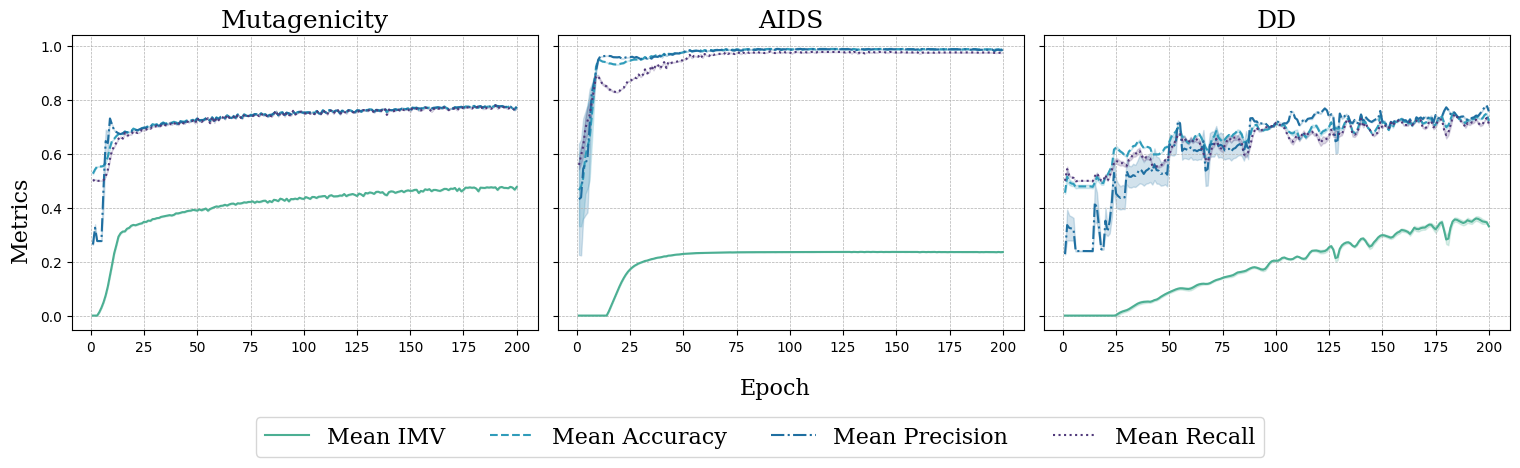

In [ ]:
import matplotlib.pyplot as plt

# Create a figure with 1x3 subplots
fig, axs = plt.subplots(1, 3, figsize=(15, 5), sharex=True, sharey=True)

# Define colors, labels, and line styles
colors = ['#4caf93', '#2f9cba', '#1f6fa1', '#50397b']
line_styles = ['-', '--', '-.', ':']
metrics = ['imv', 'accuracy', 'precision', 'recall']
y_labels = ['IMV', 'Accuracy', 'Precision', 'Recall']
titles = ['Mutagenicity', 'AIDS', 'DD']

font = {
    'family': 'serif',
    'weight': 'normal',
    'size': 18,
}

label_font = {
    'family': 'serif',
    'weight': 'normal',
    'size': 16,
}

# Plot for each dataset with its corresponding summary DataFrame
summary_dfs = [summary_df, summary_df_2, summary_df_3]  # Replace with actual DataFrames
for ax, summary_df, title in zip(axs, summary_dfs, titles):
    # Plot each metric with different line styles
    for metric, y_label, color, line_style in zip(metrics, y_labels, colors, line_styles):
        ax.plot(summary_df['epoch'], summary_df[f'mean_{metric}'], label=f'Mean {y_label}', color=color, linestyle=line_style)
        ax.fill_between(summary_df['epoch'],
                        summary_df[f'mean_{metric}'] - summary_df[f'var_{metric}'],
                        summary_df[f'mean_{metric}'] + summary_df[f'var_{metric}'],
                        color=color, alpha=0.2)

    # Set title and grid
    ax.set_title(title, fontdict=font)
    ax.grid(True, linestyle='--', linewidth=0.5)

# Set shared labels for the entire figure
fig.text(0.5, 0.15, 'Epoch', ha='center', fontdict=label_font)
fig.text(-0.01, 0.5, 'Metrics', va='center', rotation='vertical', fontdict=label_font)

# Create a unified legend below the entire figure
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=4, prop=label_font)

# Adjust layout and move the legend down further to avoid overlap with the x-axis
plt.tight_layout(rect=[0, 0.2, 1, 0.95])  # Further increase the bottom space for the legend
plt.show()